In [1]:
# Import pandas for DataFrame operations.
import pandas as pd

# Import numpy for numerical operations.
import numpy as np

# Import matplotlib for visualization.
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations.
import seaborn as sns

In [2]:
# Read the original flight dataset from the raw data folder.
df = pd.read_csv("../data/raw/flights.csv")

# Print confirmation that the dataset was loaded.
print("Dataset loaded successfully!")

# Display number of rows and columns.
print("Shape:", df.shape)

# Display first five rows.
df.head()

C:\Users\shini\AppData\Local\Temp\ipykernel_18608\2874832706.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/flights.csv")


Dataset loaded successfully!
Shape: (5819079, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Display information about columns, data types and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [4]:
# Count duplicate rows in the complete dataset.
duplicate_count = df.duplicated().sum()

# Print the number of duplicate records.
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [5]:
# Count missing values in every column.
missing_values = df.isnull().sum()

# Sort missing values from highest to lowest.
missing_values = missing_values.sort_values(ascending=False)

# Display the result.
missing_values

CANCELLATION_REASON    5729195
WEATHER_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
AIRLINE_DELAY          4755640
SECURITY_DELAY         4755640
AIR_SYSTEM_DELAY       4755640
AIR_TIME                105071
ARRIVAL_DELAY           105071
ELAPSED_TIME            105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
TAXI_OUT                 89047
WHEELS_OFF               89047
DEPARTURE_DELAY          86153
DEPARTURE_TIME           86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
SCHEDULED_DEPARTURE          0
CANCELLED                    0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
SCHEDULED_ARRIVAL            0
DIVERTED                     0
ORIGIN_AIRPORT               0
DISTANCE                     0
DESTINATION_AIRPORT          0
MONTH                        0
YEAR                         0
dtype: int64

In [6]:
# Calculate the percentage of missing values in every column.
missing_percentage = (
    df.isnull().mean() * 100
)

# Sort the percentages from highest to lowest.
missing_percentage = missing_percentage.sort_values(
    ascending=False
)

# Display missing-value percentages.
missing_percentage

CANCELLATION_REASON    98.455357
WEATHER_DELAY          81.724960
LATE_AIRCRAFT_DELAY    81.724960
AIRLINE_DELAY          81.724960
SECURITY_DELAY         81.724960
AIR_SYSTEM_DELAY       81.724960
AIR_TIME                1.805629
ARRIVAL_DELAY           1.805629
ELAPSED_TIME            1.805629
WHEELS_ON               1.589822
TAXI_IN                 1.589822
ARRIVAL_TIME            1.589822
TAXI_OUT                1.530259
WHEELS_OFF              1.530259
DEPARTURE_DELAY         1.480526
DEPARTURE_TIME          1.480526
TAIL_NUMBER             0.252978
SCHEDULED_TIME          0.000103
SCHEDULED_DEPARTURE     0.000000
CANCELLED               0.000000
DAY                     0.000000
DAY_OF_WEEK             0.000000
AIRLINE                 0.000000
FLIGHT_NUMBER           0.000000
SCHEDULED_ARRIVAL       0.000000
DIVERTED                0.000000
ORIGIN_AIRPORT          0.000000
DISTANCE                0.000000
DESTINATION_AIRPORT     0.000000
MONTH                   0.000000
YEAR      

In [7]:
# Create a list of columns that we do not want in our prediction dataset.
columns_to_drop = [

    # Cancellation reason is not available as a useful pre-departure prediction feature.
    "CANCELLATION_REASON",

    # These delay-reason columns are known after operational events occur.
    "WEATHER_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "AIRLINE_DELAY",
    "SECURITY_DELAY",
    "AIR_SYSTEM_DELAY",

    # Actual departure information would create leakage.
    "DEPARTURE_TIME",

    # Operational information available after/around departure.
    "TAXI_OUT",
    "WHEELS_OFF",

    # These are post-flight or operational values.
    "ELAPSED_TIME",
    "AIR_TIME",
    "WHEELS_ON",
    "TAXI_IN",
    "ARRIVAL_TIME",

    # Arrival delay happens after the departure and therefore cannot be
    # used to predict departure delay.
    "ARRIVAL_DELAY"
]

# Remove the unwanted columns.
df = df.drop(columns=columns_to_drop)

# Display the new shape.
print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (5819079, 16)


In [8]:
# Count how many flights were cancelled and not cancelled.
cancellation_counts = df["CANCELLED"].value_counts()

# Display the counts.
print(cancellation_counts)

# Calculate cancellation percentages.
cancellation_percentage = (
    df["CANCELLED"].value_counts(normalize=True) * 100
)

# Display the percentages.
print(cancellation_percentage)

CANCELLED
0    5729195
1      89884
Name: count, dtype: int64
CANCELLED
0    98.455357
1     1.544643
Name: proportion, dtype: float64


In [9]:
# Keep only flights that were not cancelled.
df = df[df["CANCELLED"] == 0].copy()

# Remove the CANCELLED column because all remaining rows are non-cancelled.
df = df.drop(columns=["CANCELLED"])

# Display the new shape.
print("Shape after removing cancelled flights:", df.shape)

Shape after removing cancelled flights: (5729195, 15)


In [10]:
# Remove aircraft tail number because it has many missing values
# and is not necessary for our baseline production model.
df = df.drop(columns=["TAIL_NUMBER"])

# Display current shape.
print("Current shape:", df.shape)

Current shape: (5729195, 14)


In [11]:
# Remove rows where scheduled flight duration is missing.
df = df.dropna(
    subset=["SCHEDULED_TIME"]
).copy()

# Display the final cleaned shape.
print("Final cleaned shape:", df.shape)

Final cleaned shape: (5729194, 14)


In [12]:
# Count missing values after cleaning.
remaining_missing = df.isnull().sum()

# Display columns that still contain missing values.
remaining_missing[remaining_missing > 0]

Series([], dtype: int64)

In [13]:
# Display statistical information about departure delay.
df["DEPARTURE_DELAY"].describe()

count    5.729194e+06
mean     9.338808e+00
std      3.699240e+01
min     -8.200000e+01
25%     -5.000000e+00
50%     -2.000000e+00
75%      7.000000e+00
max      1.988000e+03
Name: DEPARTURE_DELAY, dtype: float64

In [14]:
# Count flights that departed earlier than scheduled.
early_flights = (
    df["DEPARTURE_DELAY"] < 0
).sum()

# Count flights that had zero or positive delay.
delayed_or_on_time = (
    df["DEPARTURE_DELAY"] >= 0
).sum()

# Print both values.
print("Flights departed early:", early_flights)
print("Flights with zero/positive delay:", delayed_or_on_time)

Flights departed early: 3276871
Flights with zero/positive delay: 2452323


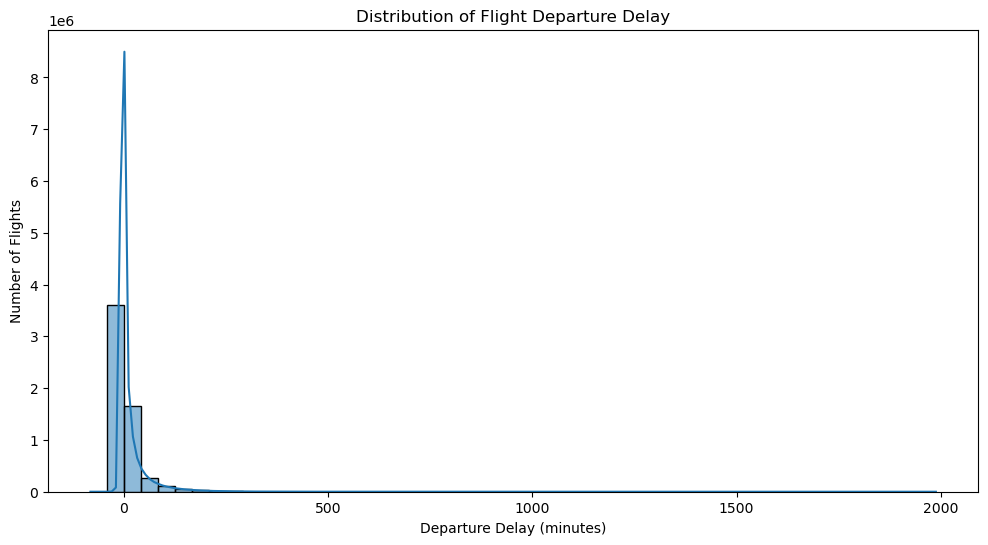

In [16]:
# Create a figure with a reasonable size.
plt.figure(figsize=(12, 6))

# Plot the distribution of departure delays.
sns.histplot(
    df["DEPARTURE_DELAY"],
    bins=50,
    kde=True
)

# Add a title.
plt.title("Distribution of Flight Departure Delay")

# Label x-axis.
plt.xlabel("Departure Delay (minutes)")

# Label y-axis.
plt.ylabel("Number of Flights")

# Display the plot.
plt.show()

In [17]:
# Calculate average departure delay for every airline.
airline_delay = (
    df.groupby("AIRLINE")["DEPARTURE_DELAY"]
    .mean()
    .sort_values(ascending=False)
)

# Display the result.
print(airline_delay)

AIRLINE
NK    15.909902
UA    14.379658
F9    13.317470
B6    11.499049
WN    10.571461
MQ    10.014910
VX     9.006274
AA     8.864029
EV     8.663310
OO     7.768222
DL     7.354815
US     6.110538
AS     1.778455
HA     0.483489
Name: DEPARTURE_DELAY, dtype: float64


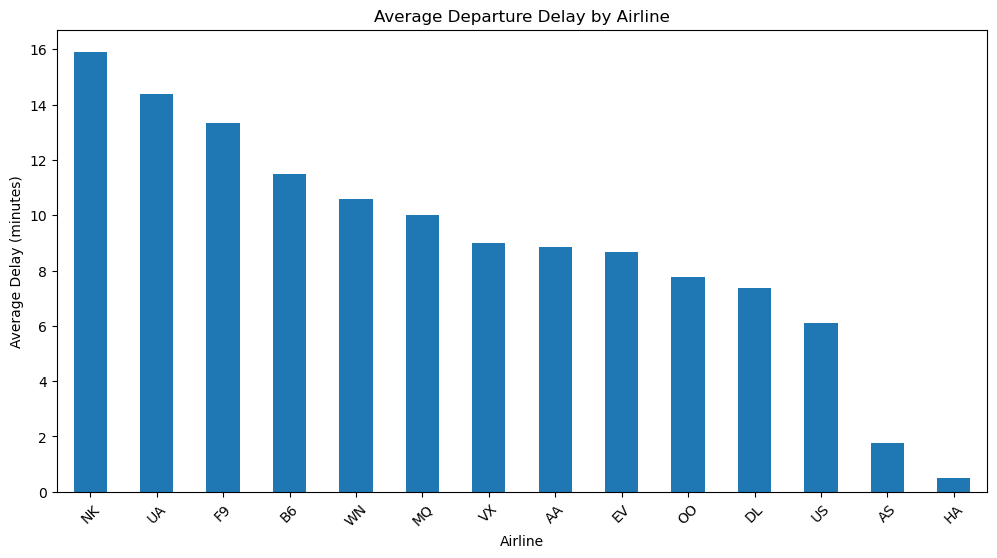

In [18]:
# Create the figure.
plt.figure(figsize=(12, 6))

# Plot average delay for each airline.
airline_delay.plot(kind="bar")

# Add title.
plt.title("Average Departure Delay by Airline")

# Label x-axis.
plt.xlabel("Airline")

# Label y-axis.
plt.ylabel("Average Delay (minutes)")

# Rotate labels for readability.
plt.xticks(rotation=45)

# Display the plot.
plt.show()

In [19]:
# Calculate average delay for each month.
monthly_delay = (
    df.groupby("MONTH")["DEPARTURE_DELAY"]
    .mean()
)

# Display monthly averages.
print(monthly_delay)

MONTH
1      9.732780
2     11.814630
3      9.627705
4      7.683748
5      9.418682
6     13.942455
7     11.374876
8      9.911056
9      4.813419
10     4.971586
11     6.922445
12    11.738865
Name: DEPARTURE_DELAY, dtype: float64


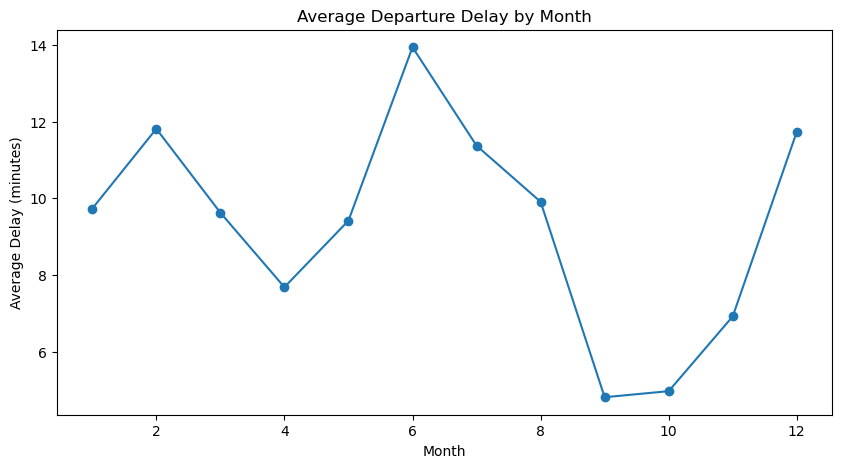

In [20]:
# Create figure.
plt.figure(figsize=(10, 5))

# Plot average monthly delay.
monthly_delay.plot(marker="o")

# Add title.
plt.title("Average Departure Delay by Month")

# Label axes.
plt.xlabel("Month")

plt.ylabel("Average Delay (minutes)")

# Display plot.
plt.show()

In [21]:
# Calculate average delay for each day of the week.
day_delay = (
    df.groupby("DAY_OF_WEEK")["DEPARTURE_DELAY"]
    .mean()
)

# Display result.
print(day_delay)

DAY_OF_WEEK
1    10.821088
2     9.142979
3     8.627734
4     9.925353
5     9.404951
6     7.788214
7     9.367854
Name: DEPARTURE_DELAY, dtype: float64


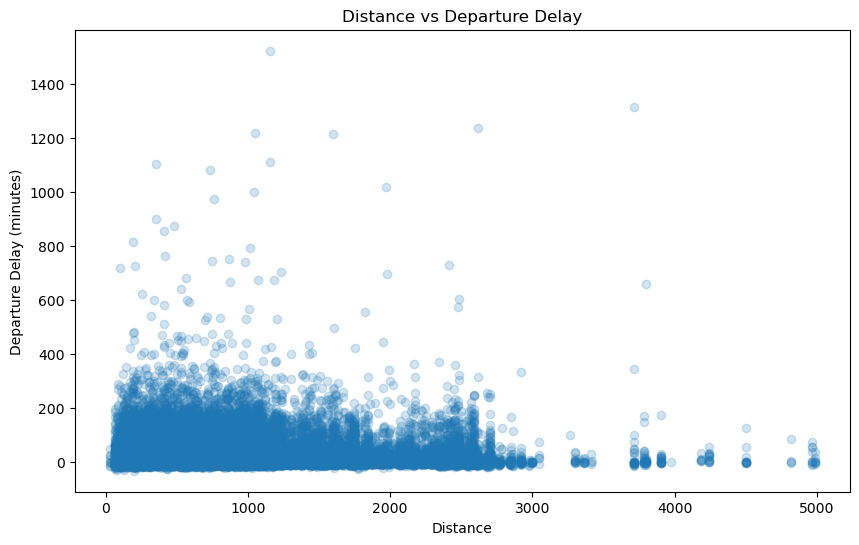

In [22]:
# Create a scatter plot between distance and departure delay.
plt.figure(figsize=(10, 6))

# Plot a sample because plotting millions of points is unnecessary.
sample_df = df.sample(
    n=min(100000, len(df)),
    random_state=42
)

# Create scatter plot using sampled records.
plt.scatter(
    sample_df["DISTANCE"],
    sample_df["DEPARTURE_DELAY"],
    alpha=0.2
)

# Add title.
plt.title("Distance vs Departure Delay")

# Label axes.
plt.xlabel("Distance")

plt.ylabel("Departure Delay (minutes)")

# Display plot.
plt.show()

In [23]:
# Calculate first quartile.
Q1 = df["DEPARTURE_DELAY"].quantile(0.25)

# Calculate third quartile.
Q3 = df["DEPARTURE_DELAY"].quantile(0.75)

# Calculate interquartile range.
IQR = Q3 - Q1

# Calculate lower boundary.
lower_bound = Q1 - 1.5 * IQR

# Calculate upper boundary.
upper_bound = Q3 + 1.5 * IQR

# Count values outside the boundaries.
outlier_count = (
    (df["DEPARTURE_DELAY"] < lower_bound) |
    (df["DEPARTURE_DELAY"] > upper_bound)
).sum()

# Display the count.
print("Outliers:", outlier_count)

Outliers: 734485


In [24]:
# Define the output path.
output_path = "../data/processed/flights_cleaned.csv"

# Save the cleaned dataset.
df.to_csv(
    output_path,
    index=False
)

# Print confirmation.
print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
../data/processed/flights_cleaned.csv
